In [ ]:
import torch
import torch.nn as nn
import numpy as np
import random

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
with open("data.txt", "r", encoding="utf-8") as f:
    text = f.read().lower()

print(text[:500])

the king walked slowly across the palace hall.
the guards stood quietly beside the tall doors.
the queen looked at the garden from the balcony.
the wind moved gently through the green trees.
the birds sang early in the morning light.

the young prince ran across the courtyard.
the soldiers trained every day before sunrise.
the castle walls stood strong against the cold wind.
the villagers gathered in the town square.
the old storyteller spoke beside the fire.

the king listened carefully to the 


In [7]:
words = text.split()

# Unique words
vocab = sorted(set(words))

# Vocabulary size
vocab_size = len(vocab)

print("Vocabulary Size:", vocab_size)

# Create mappings
word_to_ix = {word:i for i,word in enumerate(vocab)}
ix_to_word = {i:word for word,i in word_to_ix.items()}

Vocabulary Size: 329


In [8]:
seq_length = 5

inputs = []
targets = []

for i in range(len(words) - seq_length):
    seq = words[i:i+seq_length]
    target = words[i+seq_length]

    inputs.append([word_to_ix[w] for w in seq])
    targets.append(word_to_ix[target])

In [9]:
X = torch.tensor(inputs)
y = torch.tensor(targets)

print(X.shape, y.shape)

torch.Size([743, 5]) torch.Size([743])


In [10]:
class RNNModel(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size):
        super(RNNModel, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embed_size)

        self.rnn = nn.RNN(embed_size, hidden_size, batch_first=True)

        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):

        x = self.embedding(x)

        out, hidden = self.rnn(x)

        out = out[:, -1, :]

        out = self.fc(out)

        return out

In [11]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size):
        super(LSTMModel, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embed_size)

        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True)

        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):

        x = self.embedding(x)

        out, (hidden, cell) = self.lstm(x)

        out = out[:, -1, :]

        out = self.fc(out)

        return out

In [17]:
embed_size = 128
hidden_size = 256
epochs = 100

model = LSTMModel(vocab_size, embed_size, hidden_size)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [18]:
for epoch in range(epochs):

    optimizer.zero_grad()

    output = model(X)

    loss = criterion(output, y)

    loss.backward()

    optimizer.step()

    print("Epoch:", epoch+1, "Loss:", loss.item())

Epoch: 1 Loss: 5.813395023345947
Epoch: 2 Loss: 5.766617774963379
Epoch: 3 Loss: 5.719090461730957
Epoch: 4 Loss: 5.668139457702637
Epoch: 5 Loss: 5.610998153686523
Epoch: 6 Loss: 5.544605255126953
Epoch: 7 Loss: 5.465599060058594
Epoch: 8 Loss: 5.370625972747803
Epoch: 9 Loss: 5.257321357727051
Epoch: 10 Loss: 5.12684965133667
Epoch: 11 Loss: 4.9891791343688965
Epoch: 12 Loss: 4.871026515960693
Epoch: 13 Loss: 4.813412666320801
Epoch: 14 Loss: 4.80539083480835
Epoch: 15 Loss: 4.770055294036865
Epoch: 16 Loss: 4.699187755584717
Epoch: 17 Loss: 4.618315696716309
Epoch: 18 Loss: 4.546257019042969
Epoch: 19 Loss: 4.487605094909668
Epoch: 20 Loss: 4.43809175491333
Epoch: 21 Loss: 4.391324996948242
Epoch: 22 Loss: 4.342604637145996
Epoch: 23 Loss: 4.289818286895752
Epoch: 24 Loss: 4.232882022857666
Epoch: 25 Loss: 4.172806739807129
Epoch: 26 Loss: 4.110857963562012
Epoch: 27 Loss: 4.048105716705322
Epoch: 28 Loss: 3.9852421283721924
Epoch: 29 Loss: 3.922508955001831
Epoch: 30 Loss: 3.859884

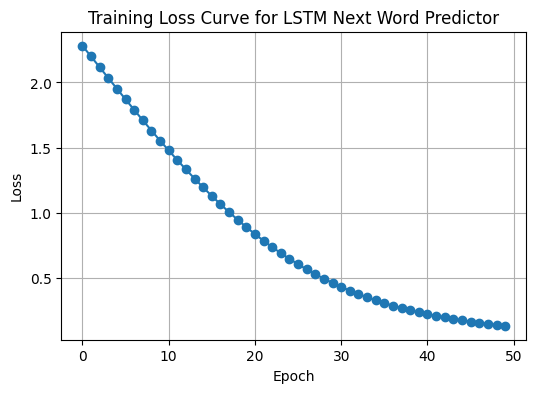

In [19]:
plt.figure(figsize=(6,4))

plt.plot(losses, marker='o')

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training Loss Curve for LSTM Next Word Predictor")

plt.grid(True)

plt.show()

In [ ]:
def generate_text(model, start_text, length=20):

    model.eval()

    words_input = start_text.lower().split()

    for i in range(length):

        seq = [word_to_ix.get(w,0) for w in words_input[-seq_length:]]

        seq = torch.tensor(seq).unsqueeze(0)

        with torch.no_grad():

            output = model(seq)

            prob = torch.softmax(output, dim=1)

            index = torch.multinomial(prob, 1).item()

            next_word = ix_to_word[index]

        words_input.append(next_word)

    return " ".join(words_input)

In [ ]:
print(generate_text(model, "\nthe king", 30))

the king prepared through the town planted nourished the soldiers welcomed the sword flashed the families the river library. brightly their secrets. in the farmers planted the interest. trained the bells morning
